<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_07_Deeplearning_for_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICT_AI_ML_ Assignment 07_Deeplearning for NLP

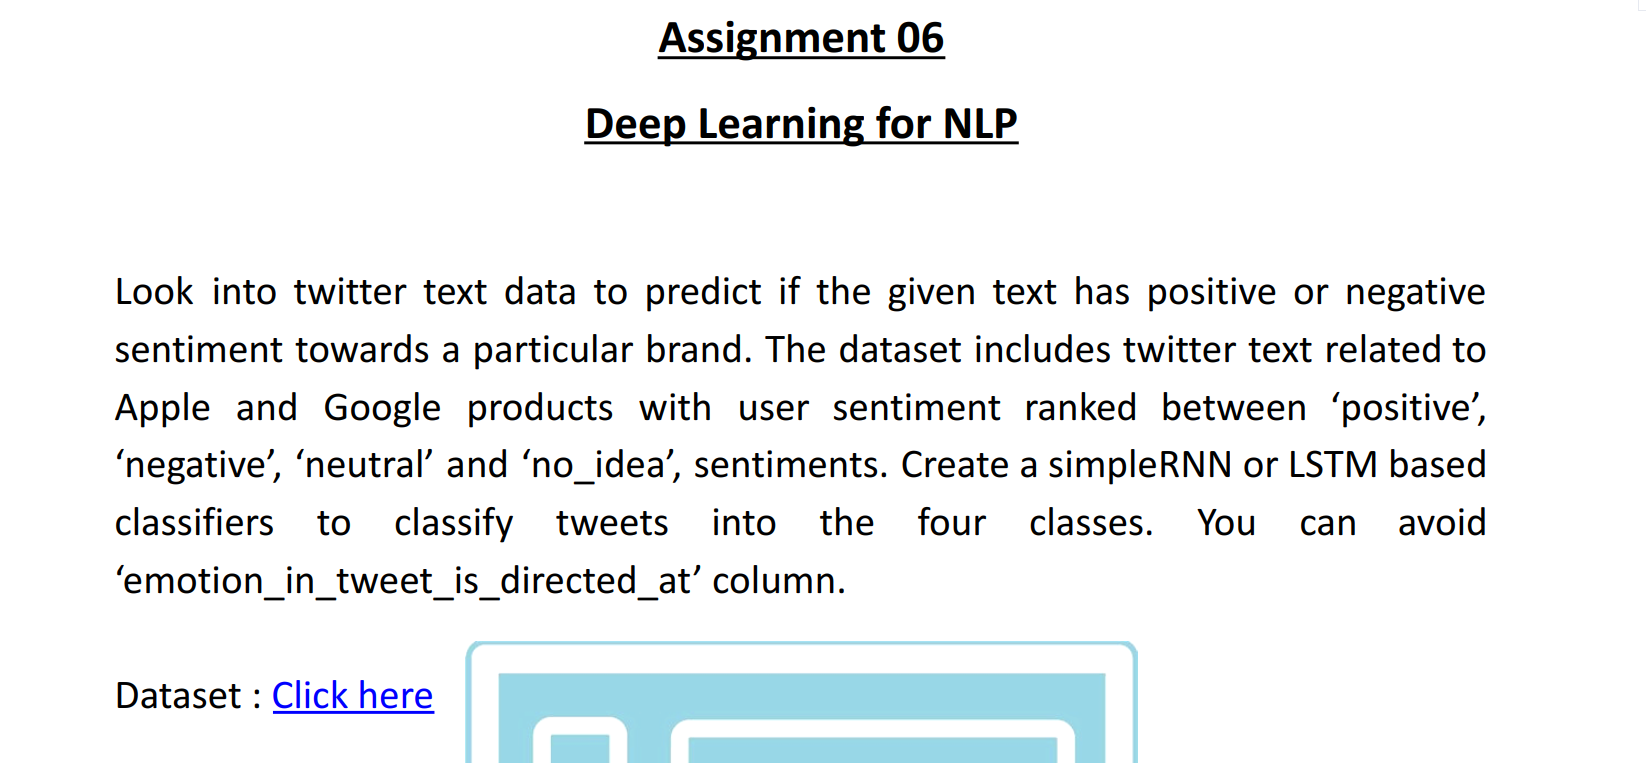

Dataset:https://drive.google.com/file/d/1HEcyWf93HxbJeC5kE0nLQH8fPevEiUhM/view

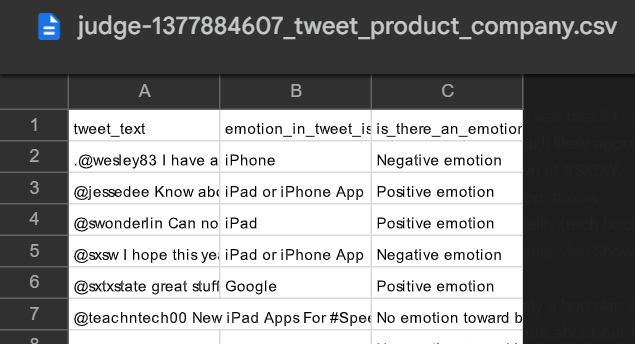

#1. Loading the data

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("judge.csv", encoding='ISO-8859-1')
df = df[['tweet_text', 'is_there_an_emotion_directed_at_a_brand_or_product']].dropna()
df.columns = ['text', 'sentiment']

#2. Preprocessing tweets

In [25]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)     # remove mentions
    text = re.sub(r"[^a-zA-Z ]", "", text)  # remove punctuation
    text = text.lower()
    return text

df['clean_text'] = df['text'].apply(clean_text)

#3. Encoding labels

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
num_classes = len(le.classes_)

# 4. Tokenization and padding

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical


tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=100)

y = to_categorical(df['label'], num_classes=num_classes)

# 5. Train-Test split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. LSTM Model

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=64, input_length=100))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 7. Training model

In [31]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.5481 - loss: 1.0306 - val_accuracy: 0.6360 - val_loss: 0.8302
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.6667 - loss: 0.7970 - val_accuracy: 0.6607 - val_loss: 0.7748
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8112 - loss: 0.5331 - val_accuracy: 0.6813 - val_loss: 0.7970
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.8534 - loss: 0.4056 - val_accuracy: 0.6813 - val_loss: 0.8760
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8769 - loss: 0.3341 - val_accuracy: 0.6731 - val_loss: 0.9368
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.8882 - loss: 0.2981 - val_accuracy: 0.6484 - val_loss: 1.0852
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.9037 - loss: 0.2572 - val_accuracy: 0.6635 - val_loss: 1.0681
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.9170 - loss: 0.2173 - 

# 8. Evaluate

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6521 - loss: 1.0451
Test Accuracy: 0.65


#9. Predict

In [22]:
sample = ["I absolutely love the new Apple iPhone!"]
sample_seq = tokenizer.texts_to_sequences([clean_text(sample[0])])
sample_pad = pad_sequences(sample_seq, maxlen=100)
pred = model.predict(sample_pad)
print(f"Predicted sentiment: {le.classes_[np.argmax(pred)]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
Predicted sentiment: Positive emotion
